### 03_RAG_result 
This is the script to analyse RAG result from the agentic RAG. 

**Importance!** 
For the full implementation of the agentic RAG pipeline, see: https://github.com/florentaden/agent-climate-disclosure

Notice that the questions have been renamed from 08_21 to 01_13

In [1]:
#!pip install wordcloud 

In [24]:
import os, re, json, time
import pandas as pd
import PyPDF2
from pathlib import Path
import glob
import numpy as np
import ast
import re
import wordcloud
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.util import ngrams
from scipy.stats import spearmanr


In [ ]:
from config_loader import load_config

cfg          = load_config()
BASE_DIR     = cfg['paths']['base_dir']
PDF_FOLDER   = cfg['paths']['pdf_folder']
ANALYSIS_DIR = cfg['paths']['analysis_dir']
RESULTS_DIR  = cfg['paths']['rag_results_dir']
FIG_FOLDER   = cfg['paths']['fig_folder']
SELECTED_PDF_LIST = cfg['paths']['selected_pdf_list']

print('PDF_FOLDER :', PDF_FOLDER)
print('RESULTS_DIR:', RESULTS_DIR)
print('FIG_FOLDER :', FIG_FOLDER)


In [26]:
# Question list
QUESTIONS = {
    9:  {
        "short": "Scenarios listed",
        "long":  "What climate scenarios or pathways are used? List all of them."
    },
    10: {
        "short": "Temperature outcome",
        "long":  "What global temperature outcomes are described, typically as targets by 2100 (e.g. 1.5°C, 2°C, 3–4°C)? Include mentions of temperature overshoot if present."
    },
    11: {
        "short": "Scenario provider",
        "long":  "Is the scenario provider explicitly named? Who is it?"
    },
    12: {
        "short": "Pick-and-mix SSP/RCP",
        "long":  "Does the document use a combination of SSPs and RCPs that are not from the same internally consistent scenario family? Answer Yes/No/not_found."
    },
    13: {
        "short": "Customised scenarios",
        "long":  "Are the scenarios described as customised or adapted for local/industry context, beyond being used off-the-shelf? Answer Yes/No/not_found."
    },
    14: {
        "short": "Co-produced scenarios",
        "long":  "Is there evidence of participatory or co-produced scenario development? Answer Yes/No/not_found."
    },
    15: {
        "short": "Baseline scenario",
        "long":  "Is a baseline or reference scenario described against which climate scenarios are compared? Answer Yes/No/not_found, and if Yes, describe it."
    },
    16: {
        "short": "Models used",
        "long":  "What climate models, integrated assessment models (IAMs), or macroeconomic models are named? Return as a JSON array."
    },
    17: {
        "short": "Acute physical risk damage",
        "long":  "Does the scenario analysis explicitly include damage or loss estimates from extreme events (acute physical risks), beyond chronic risks only? Answer Yes/No/not_found."
    },
    18: {
        "short": "Non-temperature variables",
        "long":  "What variables other than global temperature are used to drive the scenarios? Return as a JSON array."
    },
    19: {
        "short": "Scale of scenarios",
        "long":  "Are the scenarios based on global climate models, or have they been downscaled to a regional or local level? Answer 'global', 'regional/local', 'both', or 'not_found'."
    },
    20: {
        "short": "Time frames",
        "long":  "What time horizons are used for short, medium and long-term risk? Are the rationales for these timeframes explained?"
    },
    21: {
        "short": "Justification for choice",
        "long":  "Does the entity provide an explicit justification for why these specific scenarios or models were chosen? Answer Yes/No/not_found. If Yes, quote the justification."
    },
}


In [27]:
# Load submitted PDFs
df = pd.read_csv(SELECTED_PDF_LIST)
print(f'Submitted PDFs: {len(df)}')
df[['company_name','cohort', 'period_year', 'file_name']].head(5)

Submitted PDFs: 234


,company_name,cohort,period_year,file_name
0,AA INSURANCE LIMITED,FY24/25,2025,AA Insurance 2025 Climate Statement FINAL SIGN...
1,AA INSURANCE LIMITED,FY23/24,2024,AA Insurance 2024 Climate Statements.pdf
2,AFT PHARMACEUTICALS LIMITED,FY23/24,2024,240523 FY2024 Annual Report.pdf
3,AFT PHARMACEUTICALS LIMITED,FY24/25,2025,250522 AFT FY25 Annual Report.pdf
4,AIA NEW ZEALAND LIMITED,FY24/25,2024,AIA NZ Group Annual Report Dec-2024 FINAL_stam...


In [28]:
# Group: one API call per company-year, concatenating all PDFs for that period
groups = df.groupby(['company_name', 'period_year'])['file_name'].apply(list).reset_index()
print(f'Company-year groups to process: {len(groups)}')
# Check the list of file already exist
existing_files = glob.glob(os.path.join(RESULTS_DIR, '*.json'))
existing_keys  = {os.path.splitext(os.path.basename(f))[0] for f in existing_files}

def make_key(company, year):
    safe = re.sub(r'[^\w\s-]', '', company.lower())[:40].strip().replace(' ', '_')
    return f'{safe}_{year}.json'
groups['file']     = groups.apply(lambda r: make_key(r['company_name'], r['period_year']), axis=1)
groups.head()

# ---- EXCLUDE specific company-year combinations ----
exclude_list = [
    ("ANZ GROUP HOLDINGS LIMITED", 2024),
    ("HENDERSON FAR EAST INCOME LIMITED", 2024),
    ("INSURANCE AUSTRALIA GROUP LIMITED", 2024),
    ("INSURANCE AUSTRALIA GROUP LIMITED", 2025),
    ("THE BANKERS INVESTMENT TRUST PLC", 2024),
    ("WORKS FINANCE (NZ) LIMITED", 2024),
    ("WORKS FINANCE (NZ) LIMITED", 2025),
]

exclude_set = set(exclude_list)

groups = groups[
    ~groups.apply(
        lambda r: (r['company_name'], r['period_year']) in exclude_set,
        axis=1
    )
]
print(f'Company-year groups to process after exclusion: {len(groups)}')

Company-year groups to process: 234
Company-year groups to process after exclusion: 227


In [29]:
# LLM names can be diffeernt from the real name
correction_dict = {
    "china_construction_bank_new_zealand_limi_2023.json": "CHINA_CONSTRUCTION_BANK_NEW_ZEALAND_LIMITED_2023.json",
    "china_construction_bank_new_zealand_limi_2024.json": "CHINA_CONSTRUCTION_BANK_NEW_ZEALAND_LIMITED_2024.json",
    "christchurch_international_airport_limit_2024.json": "CHRISTCHURCH_INTERNATIONAL_AIRPORT_LIMITED_2024.json",
    "christchurch_international_airport_limit_2025.json": "CHRISTCHURCH_INTERNATIONAL_AIRPORT_LIMITED_2025.json",
    "fisher__paykel_healthcare_corporation_li_2024.json": "FISHER__PAYKEL_HEALTHCARE_CORPORATION_LIMITED_2024.json",
    "fisher__paykel_healthcare_corporation_li_2025.json": "FISHER__PAYKEL_HEALTHCARE_CORPORATION_LIMITED_2025.json",
    "industrial_and_commercial_bank_of_china_2024.json": "INDUSTRIAL_AND_COMMERCIAL_BANK_OF_CHINA_NEW_ZEALAN_2024.json",
    "industrial_and_commercial_bank_of_china_2023.json": "INDUSTRIAL_AND_COMMERCIAL_BANK_OF_CHINA_NEW_ZEALAN_2023.json",
    "livestock_improvement_corporation_limite_2024.json": "LIVESTOCK_IMPROVEMENT_CORPORATION_LIMITED_2024.json",
    "livestock_improvement_corporation_limite_2025.json": "LIVESTOCK_IMPROVEMENT_CORPORATION_LIMITED_2025.json",
    "millennium__copthorne_hotels_new_zealand_2023.json": "MILLENNIUM__COPTHORNE_HOTELS_NEW_ZEALAND_LIMITED_2023.json",
    "millennium__copthorne_hotels_new_zealand_2024.json": "MILLENNIUM__COPTHORNE_HOTELS_NEW_ZEALAND_LIMITED_2024.json",
    "new_zealand_king_salmon_investments_limi_2025.json": "NEW_ZEALAND_KING_SALMON_INVESTMENTS_LIMITED_2025.json",
    "new_zealand_king_salmon_investments_limi_2024.json": "NEW_ZEALAND_KING_SALMON_INVESTMENTS_LIMITED_2024.json",
    "new_zealand_local_government_funding_age_2024.json": "NEW_ZEALAND_LOCAL_GOVERNMENT_FUNDING_AGENCY_LIMITE_2024.json",
    "the_hongkong_and_shanghai_banking_corpor_2023.json": "THE_HONGKONG_AND_SHANGHAI_BANKING_CORPORATION_LIMI_2023.json",
}
correction_dict = {k.lower(): v.lower() for k, v in correction_dict.items()}
# Compile all JSON results into a flat DataFrame
records = []

for json_file in sorted(Path(RESULTS_DIR).glob('*.json')):
    stem  = json_file.stem
    parts = stem.rsplit('_', 1)
    company_slug = parts[0]
    year         = int(parts[1]) if len(parts) == 2 and parts[1].isdigit() else None

    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            questions = json.load(f).get('answers')
    except Exception as e:
        print(f'  Parse error {json_file.name}: {e}')
        continue

    row = {'file': json_file.name, 'company_slug': company_slug, 'year': year}
    for q in questions:
        qid = q.get('q_id')
        row[f'Q{qid}_answer']     = str(q.get('answer', ''))
        row[f'Q{qid}_confidence'] = q.get('confidence', '')
        row[f'Q{qid}_evidence']   = q.get('evidence', '')
        row[f'Q{qid}_verification'] = q.get('verification','')
    records.append(row)

llm_results = pd.DataFrame(records)
llm_results["file"] = llm_results["file"].str.lower()

groups['file'] = groups['file'].apply(lambda f: correction_dict.get(f, f))

# Merge two result
llm_results = pd.merge(
                       groups,
                       llm_results,
                       how = 'left',
                       left_on = ["file"],
                       right_on = ["file"])
# Flag if it is included
llm_results['llm_flag'] = np.where(llm_results['company_slug'].notna(), 1, 0)
llm_results.to_csv(os.path.join(ANALYSIS_DIR, 'tables/Table03_RAG_results_compiled.csv'), index=False)
print(f"Compiled {llm_results['llm_flag'].sum()} results")
llm_results.head(3)

Compiled 227 results


,company_name,period_year,file_name,file,company_slug,year,Q9_answer,Q9_confidence,Q9_evidence,Q9_verification,...,Q19_verification,Q20_answer,Q20_confidence,Q20_evidence,Q20_verification,Q21_answer,Q21_confidence,Q21_evidence,Q21_verification,llm_flag
0,AA INSURANCE LIMITED,2024,[AA Insurance 2024 Climate Statements.pdf],aa_insurance_limited_2024.json,AA_INSURANCE_LIMITED,2024,"['Orderly: Net Zero 2050', 'Disorderly: Delaye...",high,Scenario narratives: Orderly: Net Zero 2050* |...,None,...,None,Transition analysis: Short = Present day–2025;...,high,Table 2: Scenarios and time horizons used in o...,None,Yes,high,"As a New Zealand-based General Insurer, we con...",None,1
1,AA INSURANCE LIMITED,2025,[AA Insurance 2025 Climate Statement FINAL SIG...,aa_insurance_limited_2025.json,AA_INSURANCE_LIMITED,2025,['Orderly (ICNZ Orderly / NGFS Net Zero 2050 /...,high,"Key sources: ICNZ Orderly, NGFS Net zero 2050,...",None,...,None,Short term: 2025–2030; Medium term: 2030–2040;...,high,Short term 2025 – 2030: Aligns with our short-...,None,Yes,high,The models used in this analysis are deemed ap...,None,1
2,AFT PHARMACEUTICALS LIMITED,2024,[240523 FY2024 Annual Report.pdf],aft_pharmaceuticals_limited_2024.json,AFT_PHARMACEUTICALS_LIMITED,2024,['Ambitious and orderly - Net Zero 2050 (SSP1-...,high,We analysed three different scenarios: 'ambiti...,None,...,None,Four time horizons are defined: Short-term (le...,high,Short-term: Less than 1 year (aligned with sto...,None,Yes,medium,The approach to developing the scenarios was b...,None,1


In [10]:
# Run FIGURE 3 ##################
llm_results = pd.read_csv(os.path.join(ANALYSIS_DIR,'tables/Table03_RAG_results_compiled.csv'))

# RAG-assisted extraction quality.   
# Confidence and found flag
def col_to_label(col):
    key = col.replace('_confidence', '')
    num = int(re.search(r'\d+', key).group())
    short = QUESTIONS.get(num, {}).get('short', key)
    return f'[Q{num-8}]: {short}'

def found_flag(val):
    if pd.isna(val):
        return np.nan
    if str(val).strip().lower() == 'not_found':
        return 'not_found'
    return 'found'

# ── Data prep ──────────────────────────────────────────────────────────────────
conf_cols   = [c for c in llm_results.columns if c.endswith('_confidence')]
answer_cols = [c for c in llm_results.columns if c.endswith('_answer')]

conf_summary = llm_results[conf_cols].apply(pd.Series.value_counts).fillna(0).astype(int)
conf_summary.columns = [col_to_label(c) for c in conf_summary.columns]
level_order  = [l for l in ['high', 'medium', 'low', 'unknown'] if l in conf_summary.index]
conf_summary = conf_summary.reindex(level_order)

found_summary = llm_results[answer_cols].applymap(found_flag).apply(pd.Series.value_counts).fillna(0).astype(int)
found_summary.columns = [col_to_label(c.replace('_answer', '_confidence')) for c in found_summary.columns]

# Turn confidence score and found score into numeric
CONF_SCORE = {'high': 3, 'medium': 2, 'low': 1, 'unknown': 0}
conf_numeric  = llm_results[conf_cols].apply(lambda col: col.map(CONF_SCORE))
found_numeric = llm_results[answer_cols].applymap(found_flag).apply(lambda col: col.map({'found': 1, 'not_found': 0}))
conf_numeric.columns  = [c.replace('_confidence', '') for c in conf_cols]
found_numeric.columns = [c.replace('_answer', '')     for c in answer_cols]
common_cols = [c for c in conf_numeric.columns if c in found_numeric.columns]


corr_records = []
for col in common_cols:
    x = conf_numeric[col]
    y = found_numeric[col]
    mask = x.notna() & y.notna()
    if mask.sum() >= 2:
        r, p = spearmanr(x[mask], y[mask])
    else:
        r, p = np.nan, np.nan
    corr_records.append({
        'question': col_to_label(f'{col}_confidence'),
        'Spearman r': r,
        'p_value': p,
    })

corr_df = pd.DataFrame(corr_records).set_index('question')
corr_df

C:\Users\QuyenN\AppData\Local\Temp\ipykernel_30260\3290432019.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  found_summary = llm_results[answer_cols].applymap(found_flag).apply(pd.Series.value_counts).fillna(0).astype(int)
C:\Users\QuyenN\AppData\Local\Temp\ipykernel_30260\3290432019.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  found_numeric = llm_results[answer_cols].applymap(found_flag).apply(lambda col: col.map({'found': 1, 'not_found': 0}))
C:\Users\QuyenN\AppData\Local\Temp\ipykernel_30260\3290432019.py:46: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(x[mask], y[mask])


,Spearman r,p_value
question,,
[Q1]: Scenarios listed,NaN,NaN
[Q2]: Temperature outcome,-0.007698,0.908172
[Q3]: Scenario provider,NaN,NaN
[Q4]: Pick-and-mix SSP/RCP,-0.026116,0.695523
[Q5]: Customised scenarios,-0.065442,0.326304
[Q6]: Co-produced scenarios,-0.102692,0.122893
[Q7]: Baseline scenario,-0.132024,0.046937
[Q8]: Models used,-0.191574,0.003764
[Q9]: Acute physical risk damage,-0.051069,0.443861


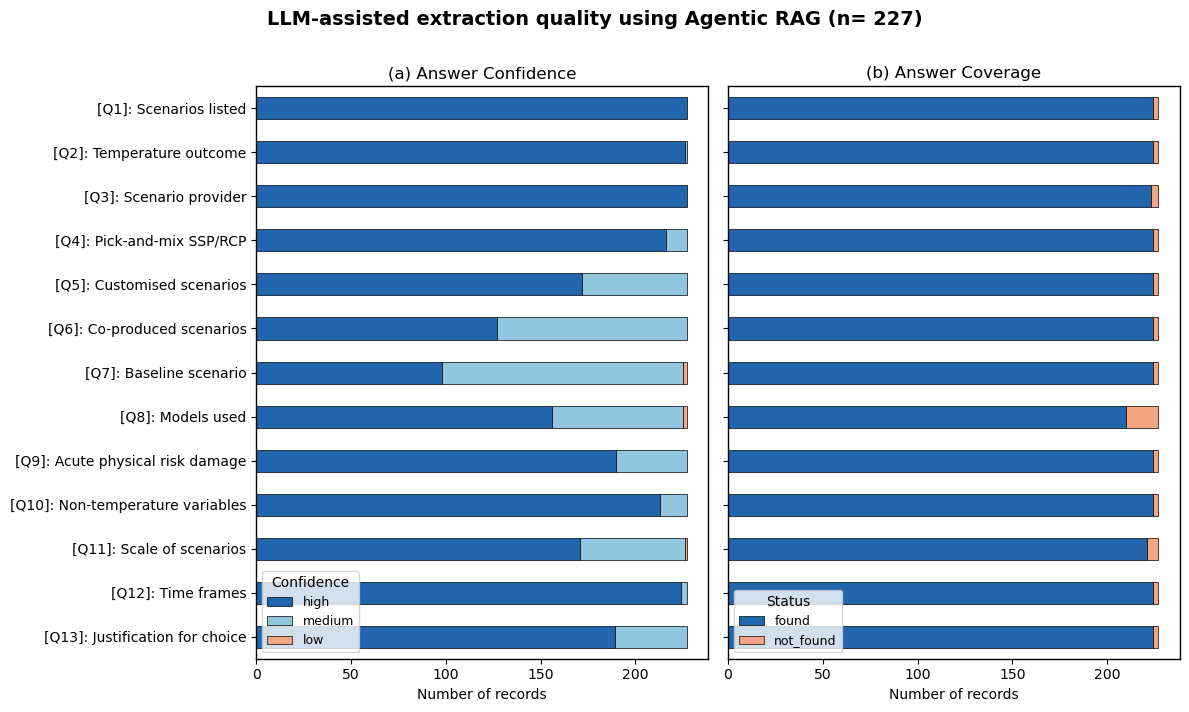

In [11]:

# ── Figure ─────────────────────────────────────────────────────────────────────
BAR_WIDTH    = 0.5
CONF_COLORS  = {'high': '#2166AC', 'medium': '#92C5DE', 'low': '#F4A582', 'unknown': '#D1D1D1'}
FOUND_COLORS = {'found': '#2166AC', 'not_found': '#F4A582'}
colors_corr = ['#2166AC' if v >= 0 else '#D6604D' for v in corr_df['Spearman r']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7),
                                     gridspec_kw={'width_ratios': [5, 5]}, sharey=True)

# Panel (a): Confidence breakdown
conf_summary.T.plot(kind='barh', stacked=True, ax=ax1, width=BAR_WIDTH,
                    color=[CONF_COLORS.get(l, '#999') for l in conf_summary.index],
                    edgecolor='black', linewidth=0.5, legend=False)
ax1.set_title('(a) Answer Confidence', fontweight='normal')
ax1.set_xlabel('Number of records')
ax1.legend(title='Confidence', loc='lower left',
           ncol=1, frameon=True, fontsize=9)

# Panel (b): Found / not_found
found_summary.T.plot(kind='barh', stacked=True, ax=ax2, width=BAR_WIDTH,
                     color=[FOUND_COLORS.get(l, '#999') for l in found_summary.index],
                     edgecolor='black', linewidth=0.5, legend=False)
ax2.set_title('(b) Answer Coverage', fontweight='normal')
ax2.set_xlabel('Number of records')
ax2.legend(title='Status', loc='lower left',
           ncol=1, frameon=True, fontsize=9)

# Reverse axis 
ax1.invert_yaxis()   # works on the shared axis once everything is drawn

# Add edge color
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

plt.suptitle(f'LLM-assisted extraction quality using Agentic RAG (n= {llm_results.shape[0]})', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_FOLDER, 'Fig06_llm_quality_overview.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [46]:
found_summary.T.to_csv(os.path.join(ANALYSIS_DIR,"tables/Table04_found_summary_AgenticRAG.csv")) 

In [32]:
# Read manual map
# Scenario list
llm_results = pd.read_csv(os.path.join(ANALYSIS_DIR, 'tables/Table03_RAG_results_compiled.csv'))

# Map scenario 
scenario_counts_rename = pd.read_csv(
    os.path.join(ANALYSIS_DIR, "interim_results/list_of_climate_scenarios_RAG_renamed.csv"),
    encoding='latin1'
)
#Addistional model 
additional_model = pd.read_csv(os.path.join(ANALYSIS_DIR, 'interim_results/List_of_mapped_models.csv'), encoding='latin1')

#First combine scenario datas 
def parse_answer(val):
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else [result]
    except:
        return [val]
    
def normalise_scenario(name):
    s = str(name).strip()
    s_lower = s.lower()
    for pattern, canonical in SCENARIO_MAP.items():
        if re.search(pattern, s_lower):
            return canonical
    # Fallback: title-case and clean whitespace
    return re.sub(r'\s+', ' ', s).strip()

def extract_list_items(val):
    if pd.isna(val) or str(val).strip().lower() == 'not_found':
        return []
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else [str(val).strip()]
    except:
        return [str(val).strip()]

def normalise_with_map(val, map_dict):
    s = str(val).strip().lower()
    for pattern, canonical in map_dict.items():
        if re.search(pattern, s):
            return canonical
    return str(val).strip()

def extract_yes_no(val):
    if pd.isna(val) or str(val).strip().lower() == 'not_found':
        return 'Not found'
    s = str(val).strip().lower()
    if re.search(r'\byes\b', s): return 'Yes'
    if re.search(r'\bno\b', s):  return 'No'
    return 'Not found'

def add_spines(ax):
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

def label_bars_h(ax, df, val_col):
    for i, (_, row) in enumerate(df.iterrows()):
        ax.text(row[val_col] + 0.1, i, str(row[val_col]), va='center', fontsize=9)

def label_bars_v(ax, df, val_col):
    for i, row in df.iterrows():
        ax.text(i, row[val_col] + 0.2, str(row[val_col]),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Q16: Models ───────────────────────────────────────────────────────────────
UNNAMED_PATTERNS = [
    r'proprietary', r'unnamed', r'not (explicitly )?named',
    r'various', r'general', r'internal', r'in-house', r'bespoke',
    r'stochastic model', r'not a model', r'not specified',
    r'no (specific )?model', r'not disclosed', r'custom model',
]

MODEL_MAP = {
    # ── GCMs / ESMs / Reanalysis ──────────────────────────────────────────────
    r'cmip\s*6':                                    'CMIP5/6 models',
    r'cmip\s*5':                                    'CMIP5/6 models',
    r'cmip(?!\s*[56])':                             'CMIP5/6 models',
    r'cordex':                                      'CORDEX',
    r'hadgem|hadcm':                                'HadGEM',
    r'access[\s-]*(cm|esm)':                        'ACCESS',
    r'miroc':                                       'MIROC',
    r'gfdl':                                        'GFDL',
    r'mpi[\s-]*esm':                                'MPI-ESM',
    r'cesm':                                        'CESM',
    r'ec[\s-]*earth':                               'EC-Earth',
    r'canesm':                                      'CanESM',
    r'ipsl[\s-]*cm':                                'IPSL-CM',
    r'cnrm[\s-]*cm':                                'CNRM-CM',
    r'era[\s-]*5\b':                                'ERA5',
    r'merra[\s-]*2?':                               'MERRA',
    r'jra[\s-]*55':                                 'JRA-55',
    r'\brcm\b|regional climate model':              'RCM',
    r'vcsn|virtual climate station':               'VCSN (NIWA)',
    r'climpacts':                                   'CLIMPACTS',
    r'lenz\b':                                      'LENZ',
    # ── IAMs ──────────────────────────────────────────────────────────────────
    r'nigem|ni\s*gem':                              'NiGEM',
    r'gcam':                                        'GCAM',
    r'remind[\s-]*magpie':                          'REMIND-MAgPIE',
    r'\bremind\b':                                  'REMIND-MAgPIE',
    r'message[\s-]*globiom':                        'MESSAGE-GLOBIOM',
    r'\bdice\b':                                    'DICE',
    r'isimip':                                      'ISIMIP',
    r'\btimes\b':                                   'TIMES',
    r'\bigsm\b':                                    'IGSM',
    r'iiasa\s*(iam)?':                              'IIASA IAM',
    r'iea\s*(weo|world energy outlook)':            'IEA-related model',
    r'\biea\b':                                     'IEA-related model',
    r'e3me':                                        'E3ME',
    r'e3\s*modelling':                              'E3ME',
    r'nemo\b':                                      'NEMO',
    r'nztm|new zealand treasury model':             'NZTM/Treasury',
    r'treasury.*cge|cge.*model':                    'NZTM/Treasury',
    r'oxford economics.*gem|oxford.*global economic model': 'Oxford Economics GEM',
    r'oxford economics':                            'Oxford Economics GEM',
    # ── Physical risk / catastrophe ───────────────────────────────────────────
    r'climada':                                     'CLIMADA',
    r'riskscape':                                   'RiskScape',
    r'moody.?s rms|\brms\b':                        "Moody's RMS",
    r'air worldwide|air catastrophe':               'AIR Worldwide',
    r'aqueduct':                                    'Aqueduct (WRI)',
    r'jupiter intelligence|climatescore':           'Jupiter Intelligence',
    r'aon.*cip|climate impact potential':           'Aon CIP',
    r'four twenty seven|427\b':                     'Four Twenty Seven',
    r'corelogic':                                   'CoreLogic',
    r'jba (risk|consulting)':                       'JBA Risk Management',
    r'climate resilience tracker':                  'Climate Resilience Tracker',
    r'flood damage assessment|fda tool':            'Flood Damage Assessment Tool',
    r'severe air':                                  'Severe Air',
    # ── ESG / financial data ──────────────────────────────────────────────────
    r's&p.*trucost|trucost':                        'S&P Trucost/Global',
    r's&p global':                                  'S&P Trucost/Global',
    r'msci esg|msci climate':                       'MSCI ESG',
    r'sustainalytics':                              'Sustainalytics',
    r'iss esg':                                     'ISS ESG',
    r'bloomberg\s*(nef|terminal)?':                 'Bloomberg',
    r'refinitiv':                                   'Refinitiv',
    # ── Consultancy / proprietary platforms ───────────────────────────────────
    r'baringa':                                     'Baringa',
    r'vivid economics':                             'Vivid Economics',
    r'entura':                                      'Entura',
    r'bcg\b|boston consulting':                     'BCG',
    r'deloitte.*model|deloitte.*tool':              'Deloitte/PwC/KPMG',
    r'pwc.*model|pwc.*tool':                        'Deloitte/PwC/KPMG',
    r'kpmg.*model|kpmg.*tool':                      'Deloitte/PwC/KPMG',
    # ── NZ-specific ───────────────────────────────────────────────────────────
    r'niwa':                                        'NIWA',
    r'mfe|ministry for the environment':            'MfE',
    r'ccc\b|climate change commission':             'Climate Change Commission',
    r'step tool|strategic energy planning':         'STEP Tool',
    r'nzaem':                                       'NZAEM',
    r'linz\b':                                      'LINZ',
    r'ecan|environment canterbury':                 'ECan',
    # ── Scenario frameworks ───────────────────────────────────────────────────
    r'ngfs':                                        'NGFS',
    r'ipcc\s*ar6|ar6\b':                            'IPCC AR5/6',
    r'ipcc\s*ar5|ar5\b':                            'IPCC AR5/6',
    r'rcp\s*8\.5h?\+?':                             'SSP/RCP families',
    r'rcp\s*4\.5':                                  'SSP/RCP families',
    r'rcp\s*2\.6':                                  'SSP/RCP families',
    r'ssp\s*5[\s-]*8\.5|ssp585':                    'SSP/RCP families',
    r'ssp\s*2[\s-]*4\.5|ssp245':                    'SSP/RCP families',
    r'ssp\s*1[\s-]*2\.6|ssp126':                    'SSP/RCP families',
    r'sbti|science.based targets':                  'SBTi',
    r'tcfd':                                        'TCFD Framework',
    r'waterproof cities':                           'Waterproof Cities',
}


additional_model = additional_model[
    pd.notna(additional_model['model']) &
    (additional_model['model'] != 'model') &
    pd.notna(additional_model['Name'])
].drop_duplicates(subset='Name')

new_entries = {
    re.escape(row['Name'].strip().lower()): row['model'].strip()
    for _, row in additional_model.iterrows()
    if row['Name'].strip().lower() not in MODEL_MAP  # don't overwrite existing patterns
}
MODEL_MAP.update(new_entries)
print(f'Added {len(new_entries)} entries from List_of_mapped_models.csv')
      
def extract_models(val):
    if pd.isna(val) or str(val).strip().lower() == 'not_found':
        return []
    items = extract_list_items(val)
    found = []
    for item in items:
        s = str(item).strip().lower()
        if any(re.search(p, s) for p in UNNAMED_PATTERNS):
            found.append('Proprietary / Unnamed')
            continue
        matched = [canonical for pattern, canonical in MODEL_MAP.items()
                   if re.search(pattern, s)]
        if matched:
            found.extend(matched)
        else:
            if len(s) < 40:
                found.append(str(item).strip())
    return list(dict.fromkeys(found))



# Canonical name lookup for known scenarios
SCENARIO_MAP = {
    # Temperature targets
    r'1\.5\s*°?\s*c': '1.5°C',
    r'2\s*°?\s*c\b': '2°C',
    r'3\s*°?\s*c\b': '3°C',
    r'4\s*°?\s*c\b': '4°C',
    r'3[\s–-]+4\s*°?\s*c': '3–4°C',
    # RCPs
    r'rcp\s*2\.6': 'RCP2.6',
    r'rcp\s*4\.5': 'RCP4.5',
    r'rcp\s*6\.0': 'RCP6.0',
    r'rcp\s*8\.5': 'RCP8.5',
    # SSPs
    r'ssp\s*1[-\s]*1\.9': 'SSP1-1.9',
    r'ssp\s*1[-\s]*2\.6': 'SSP1-2.6',
    r'ssp\s*2[-\s]*4\.5': 'SSP2-4.5',
    r'ssp\s*3[-\s]*7\.0': 'SSP3-7.0',
    r'ssp\s*5[-\s]*8\.5': 'SSP5-8.5',
    # SSPs only
    r'ssp\s*1[-\s]*': 'SSP1',
    r'ssp\s*2[-\s]*': 'SSP2',
    r'ssp\s*3[-\s]*': 'SSP3',
    r'ssp\s*5[-\s]*': 'SSP5',
    # Common named scenarios
    r'net\s*zero': 'Net Zero',
    r'business[\s-]+as[\s-]+usual|bau': 'Business as Usual',
    r'current\s+policies?': 'Current Policies',
    r'orderly': 'Orderly Transition',
    r'disorderly': 'Disorderly Transition',
    r'hot\s*house\s*world': 'Hothouse World',
    r'hot[\s-]*house[\s-]*': 'Hothouse World',
    r'hot[\s-]*house(?!\s*)': 'Hothouse World',
    r'ngfs\s*net\s*zero': 'Net Zero',
    r'taiwind*': 'CCC Tailwinds',
    r'headwind*': 'CCC Headwinds',
    r'1.5-degree*':'1.5°C',
    r'little*':'Too Little, Too late',
    r'delayed*':'Delayed Transition',
    r'too.little.too.late':           'Too Little, Too Late',
    r'delayed.transition':            'Disorderly Transition',
    r'limited.climate.action':        'Disorderly Transition',
    r'slow.follow':                   'Slow Followers',
    r'fast.follow':                   'Fast Followers',
    r'adaptive.evolution':            'Adaptive Evolution',
    r'decisive':                      'Decisive & Decisive',
    r'rapid.transition':              'Rapid Transition',
    r'world.divided|fragmented':      'Fragmented World',
    r'amber.light':                   'Amber Light',
    r'red.light':                     'Red Light',
    r'green.tap':                     'Green Taper',
    r'iea.*announ|announced.pledg':   'IEA Announced Pledges',
    r'step.scenario|step\s+\d':       'STEP Scenario',
    r'spanz':                         'SPANZ Scenario',
    r'scenario\s+\d|scenario\s+[a-c]': 'Unnamed Numbered Scenario',
    r'ngfs.*net.?zero|net.?zero.*ngfs': 'Net Zero',
    r'current.polic|ndc':             'Current Policies / NDC',
}


scenario_list = [
    item
    for answer in llm_results['Q9_answer'].dropna()
    if str(answer).strip().lower() != 'not_found'
    for item in parse_answer(answer)
]

scenario_list_norm = [normalise_scenario(s) for s in scenario_list]

# Frequency count
scenario_counts = pd.DataFrame(
    Counter(scenario_list_norm).most_common(),
    columns=['scenario', 'count']
)



scenario_counts_rename_dict = {
    str(orig).strip().lower(): str(rename).strip()
    for orig, rename in zip(
        scenario_counts_rename['scenario'],
        scenario_counts_rename['scenario_renamed'],
    )
}

scenario_list_norm = [
    scenario_counts_rename_dict.get(str(s).strip().lower(), s)
    for s in scenario_list_norm
]
scenario_counts.head(15)

Added 154 entries from List_of_mapped_models.csv


,scenario,count
0,Orderly Transition,142
1,1.5°C,101
2,Hothouse World,74
3,3°C,68
4,2°C,58
5,Net Zero,56
6,Current Policies,49
7,RCP8.5,37
8,RCP2.6,33
9,SSP2-4.5,32


### Temperature Outcome

In [60]:
# Scenario list
llm_results = pd.read_csv(os.path.join(ANALYSIS_DIR, 'tables/Table03_RAG_results_compiled.csv'))

TEMP_PATTERN = re.compile(
    r'(\d+(?:\.\d+)?)\s*(?:to|–|-|or)\s*(\d+(?:\.\d+)?)\s*°?\s*c'  # range: 1.5–2°C
    r'|(\d+(?:\.\d+)?)\s*°\s*c'                                       # single: 1.5°C
    r'|(\d+(?:\.\d+)?)\s*degrees?\s*c(?:elsius)?',                    # "2 degrees C"
    re.IGNORECASE
)

def extract_temperatures(val):
    if pd.isna(val) or str(val).strip().lower() == 'not_found':
        return []
    results = []
    for m in TEMP_PATTERN.finditer(str(val)):
        if m.group(1) and m.group(2):          # range
            results.append(f'{m.group(1)}–{m.group(2)}°C')
        elif m.group(3):                        # single with °
            results.append(f'{m.group(3)}°C')
        elif m.group(4):                        # "X degrees C"
            results.append(f'{m.group(4)}°C')
    return results


temp_list = [
    t
    for val in llm_results['Q10_answer'].dropna()
    for t in extract_temperatures(val)
]

temp_counts = pd.DataFrame(
    Counter(temp_list).most_common(),
    columns=['temperature', 'count']
)

def temp_bucket(t):
    if pd.isna(t) or str(t).strip().lower() in ('not_found', 'not found', ''):
        return 'Not Found'

    nums = [float(n) for n in re.findall(r'\d+(?:\.\d+)?', str(t))]
    if not nums:
        return 'Unknown'

    low = nums[0]
    high = nums[1] if len(nums) > 1 else low

    # 1. Exact values first
    if low == high == 1.5:
        return '1.5°C'
    if low == high == 2.0:
        return '2°C'
    if low == high == 3.0:
        return '3°C'
    if low == high == 4.0:
        return '4°C'

    # 2. Sub-1.5 range
    if high < 1.5:
        return '<1.5°C'

    # 3. 1.5–2 range
    if low >= 1.5 and high <= 2.0:
        return '1.5-2°C'

    # 4. Broad ≤2 (only if you truly need it)
    if high <= 2.0:
        return '≤2°C'

    # 5. Higher ranges
    if low >= 2.0 and high < 3.0:
        return '2-3°C'
    if low >= 3.0 and high < 4.0:
        return '3-4°C'
    if low >= 4.0:
        return '>4°C'

    return 'Unknown'

BUCKET_ORDER = [
    '<1.5°C',
    '1.5°C',
    '1.5-2°C',
    '≤2°C',
    '2°C',
    '2-3°C',
    '3°C',
    '3-4°C',
    '4°C',
    '>4°C',
    'Unknown',
    'Not Found'
]

temp_counts['bucket'] = temp_counts['temperature'].apply(temp_bucket)
bucket_counts = (
    temp_counts.groupby('bucket')['count'].sum()
    .reindex(BUCKET_ORDER)
    .dropna()
    .astype(int)
    .reset_index()
)
# Original answer -> extracted temperature -> bucket
temp_df = (
    llm_results[['Q10_answer']]
    .copy()
    .rename(columns={'Q10_answer': 'original_answer'})
)

# Extract temperatures
temp_df['temperature'] = temp_df['original_answer'].apply(extract_temperatures)

# One row per extracted temperature
temp_df = temp_df.explode('temperature', ignore_index=True)

# Keep rows with no temperatures
temp_df['temperature'] = temp_df['temperature'].fillna('Not Found')

# Bucket
temp_df['bucket'] = temp_df['temperature'].apply(temp_bucket)

#temp_df.head(20)
temp_df.to_csv(os.path.join(ANALYSIS_DIR, "tables/Table03_list_of_climate_temperatures_RAG.csv"),
                       index=False, encoding='utf-8-sig')
temp_counts = temp_df['bucket'].value_counts()
temp_counts

bucket
1.5°C        247
3°C          197
2°C          165
2-3°C        139
<1.5°C       114
1.5-2°C       97
>4°C          67
3-4°C         50
Unknown       36
4°C           15
≤2°C          10
Not Found      3
Name: count, dtype: int64

In [51]:
llm_results = pd.read_csv(os.path.join(ANALYSIS_DIR, 'tables/Table03_RAG_results_compiled.csv'))

PROVIDER_MAP = {
    r'niwa':                          'NIWA',
    r'ipcc':                          'IPCC',
    r'mfe|ministry for the environment': 'Ministry for the Environment',
    r'ccc|climate change commission': 'Climate Change Commission',
    r'ngfs':                          'NGFS',
    r'centre for sustainable finance|csf': 'Centre for Sustainable Finance',
    r'worldbank|world bank':          'World Bank',
    r'iea\b':                         'International Energy Agency',
    r'oecd':                          'OECD',
    r'tonkin':                         'Tonkin & Taylor',
    r'financial services council':     'Financial Services Council',
    r"new zealand green building council|nzgbc":'New Zealand Green Building Council',
    r"aotearoa circle":                 'The Aotearoa Cirlce',
    r"icnz":                            'Insurance Council of New Zealand',
    r"external reporting board|xrb": 'External Reporting Board' ,
    r"new zealand banking|nzba" : "New Zealand Banking Association",
    r"spanz":                     "Shared Policy Assumptions for New Zealand"
}

def extract_providers(val):
    if pd.isna(val) or str(val).strip().lower() == 'not_found':
        return []
    s = str(val).strip().lower()
    found = [canonical for pattern, canonical in PROVIDER_MAP.items()
             if re.search(pattern, s)]
    return found if found else [str(val).strip()]

# One row per original answer, with a list of providers found
llm_results['Q11_providers'] = llm_results['Q11_answer'].apply(extract_providers)

#llm_results[['Q11_answer', 'Q11_providers']].to_csv(os.path.join(ANALYSIS_DIR, "Table03_list_of_climate_scenarios_providers.csv"),
#                       index=False, encoding='ascii', errors='ignore')
provider_counts = pd.DataFrame(
    Counter([p for providers in llm_results['Q11_providers'] for p in providers]).most_common(),
    columns=['provider', 'count']
)

In [52]:
def extract_yes_no(val):
    if pd.isna(val) or str(val).strip().lower() == 'not_found':
        return 'Not found'
    s = str(val).strip().lower()
    if re.search(r'\byes\b', s):
        return 'Yes'
    elif re.search(r'\bno\b', s):
        return 'No'
    return 'Not found'

llm_results['Q12_process'] = llm_results['Q12_answer'].apply(extract_yes_no)
llm_results['Q13_process'] = llm_results['Q13_answer'].apply(extract_yes_no)
print(llm_results['Q13_process'].value_counts())
llm_results['Q14_process'] = llm_results['Q14_answer'].apply(extract_yes_no)
print(llm_results['Q14_process'].value_counts())


Q13_process
Yes          209
No            15
Not found      3
Name: count, dtype: int64
Q14_process
No           135
Yes           89
Not found      3
Name: count, dtype: int64


In [ ]:
llm_results['Q15_process'] = llm_results['Q15_answer'].apply(extract_yes_no)
q15_count = llm_results['Q15_process'].value_counts().to_frame().reset_index()
q15_count

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2565703376.py, line 3)

In [54]:
#Model check 
llm_results['Q16_models'] = llm_results['Q16_answer'].apply(extract_models)
q16_list = [m for models in llm_results['Q16_models'] for m in models]
q16_counts = pd.DataFrame(Counter(q16_list).most_common(), columns=['model', 'count'])

unmatched = [m for m in q16_list
             if m not in MODEL_MAP.values() and m != 'Proprietary / Unnamed']
print('Unmatched — consider adding to MODEL_MAP:')
pd.Series(unmatched).value_counts().to_csv(os.path.join(ANALYSIS_DIR, 'List_of_unmatched_model.csv'))
print(pd.Series(unmatched).value_counts().to_string())


Unmatched — consider adding to MODEL_MAP:
not_found                                  15
NASA Sea Level Change Portal                2
Urban Intelligence Resilience Explorer™     2
MAGICCv7.5.3                                2
GISS-E2.1                                   2
enterprise risk matrix                      1
Toitū emanage                               1
vulnerability and exposure tool             1
ESGIS geospatial platform                   1
vendor flood models                         1
LandscapeDNA                                1
Toitū emanage software                      1
council flood studies                       1
emanage                                     1
capital models                              1
EECA projections                            1
technical pricing models                    1
risk-based flood pricing models             1
GIS flood modelling                         1
ALOS elevation model                        1
capital modelling                     

In [ ]:
# ── Q17: Acute physical risk ──────────────────────────────────────────────────
q17_counts = llm_results['Q17_answer'].apply(extract_yes_no).value_counts().reset_index()
q17_counts.columns = ['answer', 'count']

# ── Q18: Non-temperature variables ───────────────────────────────────────────
VARIABLE_MAP = {
    r'sea.?level':             'Sea level rise',
    r'carbon.?price|ets':      'Carbon price',
    r'rainfall|precipitation': 'Rainfall',
    r'storm|cyclone':          'Storm frequency',
    r'oil.?price':             'Oil price',
    r'flood':                  'Flooding',
    r'drought':                'Drought',
    r'wind':                   'Wind',
    r'temperature':            'Temperature',
    r'gdp|economic\s+growth':  'GDP / Economic growth',
    r'green.?tech|renewabl':   'Green technology',
    r'population':             'Population',
    r'land.?use':              'Land use',
}

q18_list = [normalise_with_map(item, VARIABLE_MAP)
            for val in llm_results['Q18_answer'].dropna()
            for item in extract_list_items(val)]
q18_counts = pd.DataFrame(Counter(q18_list).most_common(), columns=['variable', 'count'])

# ── Q19: Scale ────────────────────────────────────────────────────────────────
SCALE_MAP = {
    r'both|global.*local|local.*global|downscal.*global|regional.*global': 'both',
    r'regional|local|downscal|national|country':                           'regional/local',
    r'global':                                                             'global',
}

def extract_scale(val):
    if pd.isna(val) or str(val).strip().lower() == 'not_found':
        return 'not_found'
    s = str(val).strip().lower()
    for pattern, canonical in SCALE_MAP.items():
        if re.search(pattern, s):
            return canonical
    return 'not_found'

SCALE_LABELS = {
    'global':        'Global',
    'regional/local':'Regional/Local',
    'both':          'Both',
    'not_found':     'Not Found',
}
scale_order = ['global', 'regional/local', 'both', 'not_found']
q19_counts = llm_results['Q19_answer'].apply(extract_scale).value_counts().reset_index()
q19_counts.columns = ['scale', 'count']
q19_counts = q19_counts.set_index('scale').reindex(scale_order).dropna().astype(int).reset_index()
q19_counts['scale'] = q19_counts['scale'].map(SCALE_LABELS)

# ── Q20: Time frames ──────────────────────────────────────────────────────────
YEAR_PATTERN = re.compile(r'\b(20\d{2})\b')

def extract_timeframes(val):
    if pd.isna(val) or str(val).strip().lower() == 'not_found':
        return [], False
    s = str(val)
    years = [int(y) for y in YEAR_PATTERN.findall(s)]
    has_justification = bool(re.search(
        r'because|rationale|align|consistent|chosen|selected|reflect', s, re.IGNORECASE))
    return years, has_justification

q20_years, q20_justified = [], []
for val in llm_results['Q20_answer'].dropna():
    years, justified = extract_timeframes(val)
    q20_years.extend(years)
    q20_justified.append(justified)

year_counts  = pd.DataFrame(Counter(q20_years).most_common(), columns=['year', 'count'])
justif_counts = pd.DataFrame({
    'justified': ['Yes', 'No'],
    'count': [sum(q20_justified), len(q20_justified) - sum(q20_justified)]
})

# ── Q21: Justification ────────────────────────────────────────────────────────
q21_counts = llm_results['Q21_answer'].apply(extract_yes_no).value_counts().reset_index()
q21_counts.columns = ['answer', 'count']


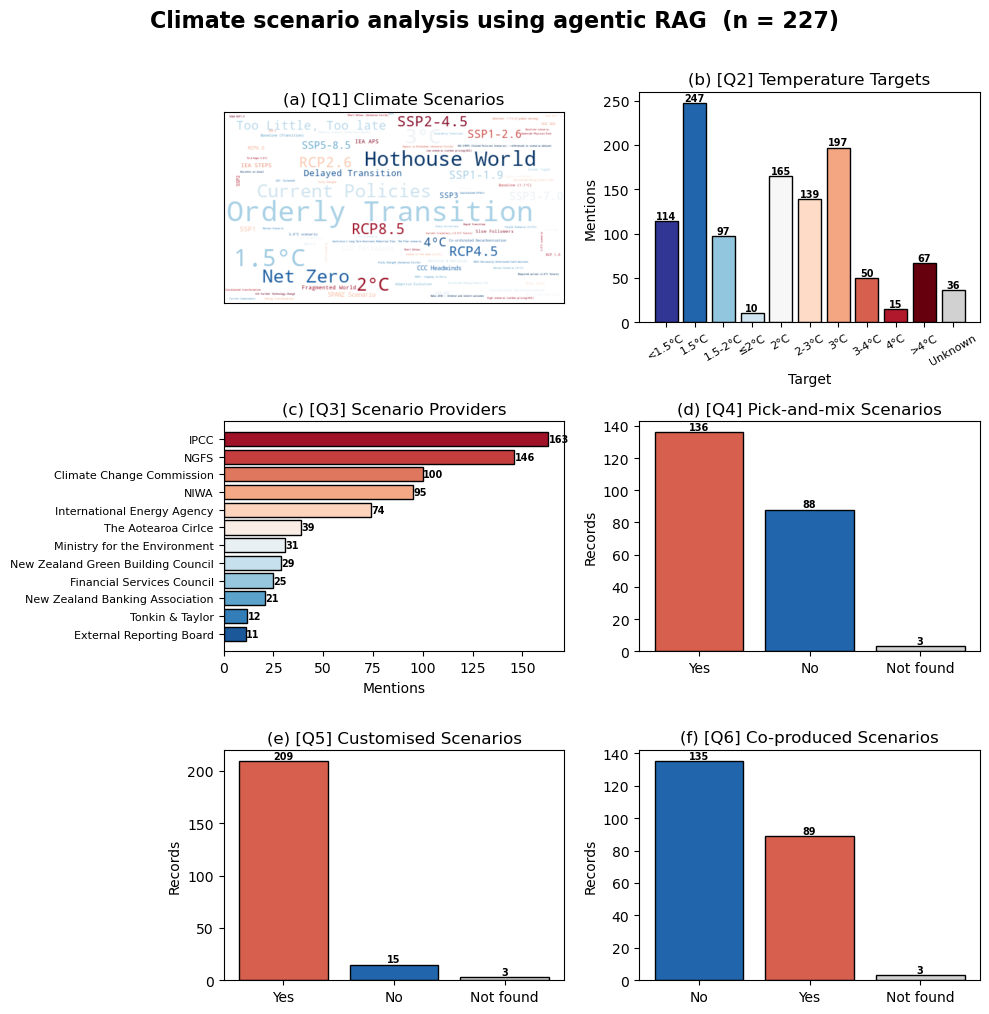

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# COMBINED FIGURE 5 - LLM-assisted cliamte scneario 
# ══════════════════════════════════════════════════════════════════════════════
BUCKET_COLORS = {
    '<1.5°C':   '#313695',
    '1.5°C':    '#2166AC',
    '1.5-2°C':  '#92C5DE',
    '≤2°C':     '#D1E5F0',
    '2°C':      '#F7F7F7',
    '2-3°C':    '#FDDBC7',
    '3°C':      '#F4A582',
    '3-4°C':    '#D6604D',
    '4°C':      '#B2182B',
    '>4°C':     '#67000D',
    'Unknown':  '#D1D1D1',
    'Not Found':'#EBEBEB',
}

YESNO_COLORS = {'Yes': '#D6604D', 'No': '#2166AC', 'Not found': '#D1D1D1'}
SCALE_COLORS = {
    'Global':         '#2166AC',
    'Regional/Local': '#4DAC26',
    'Both':           '#92C5DE',
    'Not Found':      '#D1D1D1',
}
BAR_W = 0.5

# Tokens
tokens = scenario_list_norm

freq = Counter(scenario_list_norm)

wc = WordCloud(
    width=500,
    height=280,
    background_color='white',
    colormap='RdBu'
).generate_from_frequencies(freq)

def _sp(ax):
    for s in ax.spines.values(): s.set_edgecolor('black'); s.set_linewidth(0.8)

def _lh(ax, labels, vals):
    for i, (l, v) in enumerate(zip(labels, vals)):
        ax.text(v + 0.15, i, str(v), va='center', fontsize=7, fontweight='bold')

def _lv(ax, positions, vals):
    for x, y in zip(positions, vals):
        ax.text(x, y + 0.2, str(y), ha='center',
                 va='bottom', fontsize=7, fontweight='bold')

def _trunc(s, n=40):
    s = str(s)
    return s[:n] + '…' if len(s) > n else s

fig, axes = plt.subplots(3, 2, figsize=(10,10), facecolor='white')
(ax_wc,   ax_temp, ax_prov,
 ax_q12,  ax_q13, ax_q14,
 ) = axes.flatten()

# ── (a) Scenario word cloud ───────────────────────────────────────────────────
ax_wc.imshow(wc, interpolation='bilinear')
ax_wc.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_wc.set_title('(a) [Q1] Climate Scenarios', fontweight='normal')

# ── (b) Temperature buckets ───────────────────────────────────────────────────
colors_b = [BUCKET_COLORS.get(b, '#999') for b in bucket_counts['bucket']]
ax_temp.bar(bucket_counts['bucket'], bucket_counts['count'],
            color=colors_b, edgecolor='black', linewidth=1)
_lv(ax_temp, range(len(bucket_counts)), bucket_counts['count'].tolist())
ax_temp.set_title('(b) [Q2] Temperature Targets', fontweight='normal')
ax_temp.set_xlabel('Target'); ax_temp.set_ylabel('Mentions')
ax_temp.tick_params(axis='x', labelsize=8, rotation=30); _sp(ax_temp)

# ── (c) Scenario providers ────────────────────────────────────────────────────
top_prov   = provider_counts.head(12)
prov_lbls  = [_trunc(l) for l in top_prov['provider'][::-1]]
prov_vals  = top_prov['count'][::-1].tolist()
colors_c   = sns.color_palette('RdBu', n_colors=len(top_prov))[::-1]
ax_prov.barh(prov_lbls, prov_vals, color=colors_c, edgecolor='black', linewidth=1)
_lh(ax_prov, prov_lbls, prov_vals)
ax_prov.set_title('(c) [Q3] Scenario Providers', fontweight='normal')
ax_prov.set_xlabel('Mentions')
ax_prov.tick_params(axis='y', labelsize=8)
_sp(ax_prov)

# ── (d) Pick-and-mix SSP/RCP ─────────────────────────────────────────────────
q12_c = llm_results['Q12_answer'].apply(extract_yes_no).value_counts().reset_index()
q12_c.columns = ['answer', 'count']
ax_q12.bar(q12_c['answer'], q12_c['count'],
           color=[YESNO_COLORS.get(a, '#999') for a in q12_c['answer']],
           edgecolor='black', linewidth=1)
_lv(ax_q12, range(len(q12_c)), q12_c['count'].tolist())
ax_q12.set_title('(d) [Q4] Pick-and-mix Scenarios', fontweight='normal')
ax_q12.set_ylabel('Records'); _sp(ax_q12)

# ── (e) Customised scenarios ──────────────────────────────────────────────────
q13_c = llm_results['Q13_answer'].apply(extract_yes_no).value_counts().reset_index()
q13_c.columns = ['answer', 'count']
ax_q13.bar(q13_c['answer'], q13_c['count'],
           color=[YESNO_COLORS.get(a, '#999') for a in q13_c['answer']],
           edgecolor='black', linewidth=1)
_lv(ax_q13, range(len(q13_c)), q13_c['count'].tolist())
ax_q13.set_title('(e) [Q5] Customised Scenarios', fontweight='normal')
ax_q13.set_ylabel('Records'); _sp(ax_q13)

# ── (f) Co-produced scenarios ─────────────────────────────────────────────────
q14_c = llm_results['Q14_answer'].apply(extract_yes_no).value_counts().reset_index()
q14_c.columns = ['answer', 'count']
ax_q14.bar(q14_c['answer'], q14_c['count'],
           color=[YESNO_COLORS.get(a, '#999') for a in q14_c['answer']],
           edgecolor='black', linewidth=1)
_lv(ax_q14, range(len(q14_c)), q14_c['count'].tolist())
ax_q14.set_title('(f) [Q6] Co-produced Scenarios', fontweight='normal')
ax_q14.set_ylabel('Records'); _sp(ax_q14)

plt.suptitle(f'Summary of climate scenario analysis using agentic RAG  (n = {llm_results.shape[0]})',
             fontweight='bold', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_FOLDER, 'Fig07_combined_LLM_analysis.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


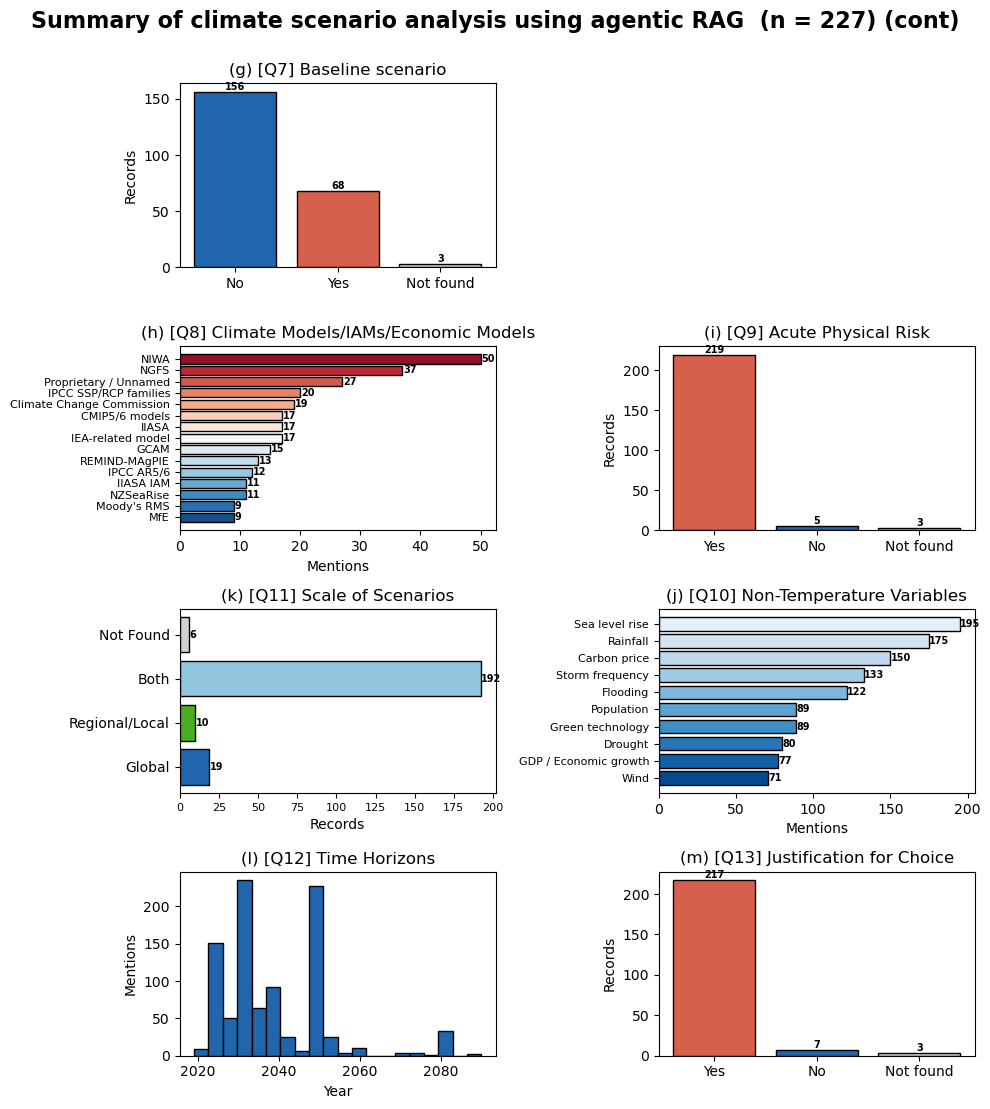

In [91]:
fig = plt.figure(figsize=(10, 12), facecolor='white')
gs = fig.add_gridspec(4, 2)

# ── Top left (Q15 uses half width) ───────────────────────────────
ax_q15 = fig.add_subplot(gs[0, 0])

# ── Bottom grid ───────────────────────────────────────────────────
ax_mod   = fig.add_subplot(gs[1, 0])
ax_q17   = fig.add_subplot(gs[1, 1])
ax_scale = fig.add_subplot(gs[2, 0])
ax_var   = fig.add_subplot(gs[2, 1])
ax_time  = fig.add_subplot(gs[3, 0])
ax_q21   = fig.add_subplot(gs[3, 1])

# ── Models used ───────────────────────────────────────────────────────────
ax_q15.bar(
    q15_count['Q15_process'],
    q15_count['count'],
    color=[YESNO_COLORS.get(a, '#999') for a in q15_count['Q15_process']],
    edgecolor='black',
    linewidth=1
)
_lv(ax_q15, range(len(q15_count)), q15_count['count'].tolist())
ax_q15.set_title('(g) [Q7] Baseline scenario', fontweight='normal')
ax_q15.set_ylabel('Records'); _sp(ax_q17)


# ── Models used ───────────────────────────────────────────────────────────
q16_top   = q16_counts.head(15)
q16_top  = q16_counts[~q16_counts['model'].isin(['not_found', 'Not Found'])].head(15)
mod_lbls  = [_trunc(l) for l in q16_top['model'][::-1]]
mod_vals  = q16_top['count'][::-1].tolist()
colors_e  = sns.color_palette('RdBu', n_colors=len(q16_top))[::-1]
ax_mod.barh(mod_lbls, mod_vals, color=colors_e, edgecolor='black', linewidth=1)
_lh(ax_mod, mod_lbls, mod_vals)
ax_mod.set_title('(h) [Q8] Climate Models/IAMs/Economic Models', fontweight='normal')
ax_mod.set_xlabel('Mentions'); ax_mod.tick_params(axis='y', labelsize=8); _sp(ax_mod)

# ──  Acute physical risk ───────────────────────────────────────────────────
ax_q17.bar(q17_counts['answer'], q17_counts['count'],
           color=[YESNO_COLORS.get(a, '#999') for a in q17_counts['answer']],
           edgecolor='black', linewidth=1)
_lv(ax_q17, range(len(q17_counts)), q17_counts['count'].tolist())
ax_q17.set_title('(i) [Q9] Acute Physical Risk', fontweight='normal')
ax_q17.set_ylabel('Records'); _sp(ax_q17)

# ──  Non-temperature variables ────────────────────────────────────────────
top_vars  = q18_counts.head(10)
var_lbls  = [_trunc(l) for l in top_vars['variable'][::-1]]
var_vals  = top_vars['count'][::-1].tolist()
colors_f  = sns.color_palette('Blues_r', n_colors=len(top_vars))
ax_var.barh(var_lbls, var_vals, color=colors_f, edgecolor='black', linewidth=1)
_lh(ax_var, var_lbls, var_vals)
ax_var.set_title('(j) [Q10] Non-Temperature Variables', fontweight='normal')
ax_var.set_xlabel('Mentions'); ax_var.tick_params(axis='y', labelsize=8); _sp(ax_var)

# ──  Scale of scenarios ────────────────────────────────────────────────────
colors_g = [SCALE_COLORS.get(s, '#999') for s in q19_counts['scale']]
ax_scale.barh(q19_counts['scale'], q19_counts['count'],
             color=colors_g, edgecolor='black', linewidth=1)
_lh(ax_scale, range(len(q19_counts)), q19_counts['count'].tolist())
ax_scale.set_title('(k) [Q11] Scale of Scenarios', fontweight='normal')
ax_scale.set_xlabel('Records'); ax_scale.tick_params(axis='x', labelsize=8); _sp(ax_scale)

# ── Time horizons histogram ───────────────────────────────────────────────
ax_time.hist(q20_years, bins=20, color='#2166AC', edgecolor='black', linewidth=1)
ax_time.set_title('(l) [Q12] Time Horizons', fontweight='normal')
ax_time.set_xlabel('Year'); ax_time.set_ylabel('Mentions'); _sp(ax_time)


# ──  Justification for scenario choice ────────────────────────────────────
ax_q21.bar(q21_counts['answer'], q21_counts['count'],
           color=[YESNO_COLORS.get(a, '#999') for a in q21_counts['answer']],
           edgecolor='black', linewidth=1)
_lv(ax_q21, range(len(q21_counts)), q21_counts['count'].tolist())
ax_q21.set_title('(m) [Q13] Justification for Choice', fontweight='normal')
ax_q21.set_ylabel('Records'); _sp(ax_q21)

plt.suptitle(f'Summary of climate scenario analysis using agentic RAG  (n = {llm_results.shape[0]}) (cont)',
             fontweight='bold', fontsize=16, y=0.92)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(FIG_FOLDER, 'Fig08_combined_LLM_analysis_continue.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
